In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# Regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')



In [7]:
# Load data
features = pd.read_csv('A.csv')
targets  = pd.read_csv('A_targets.csv')

# Gabungkan berdasarkan Student_ID
df = features.merge(targets, on='Student_ID')

print(f'Shape dataset gabungan: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head()

Shape dataset gabungan: (5000, 25)
Kolom: ['Student_ID', 'gender', 'branch', 'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 'internships_completed', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'stress_level', 'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement', 'placement_status', 'salary_lpa']


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


### Exploratory Data Analysis

In [9]:
print('Info Dataset: ')
df.info()
print('Deskriptif:')
df.describe()

Info Dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  apt

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


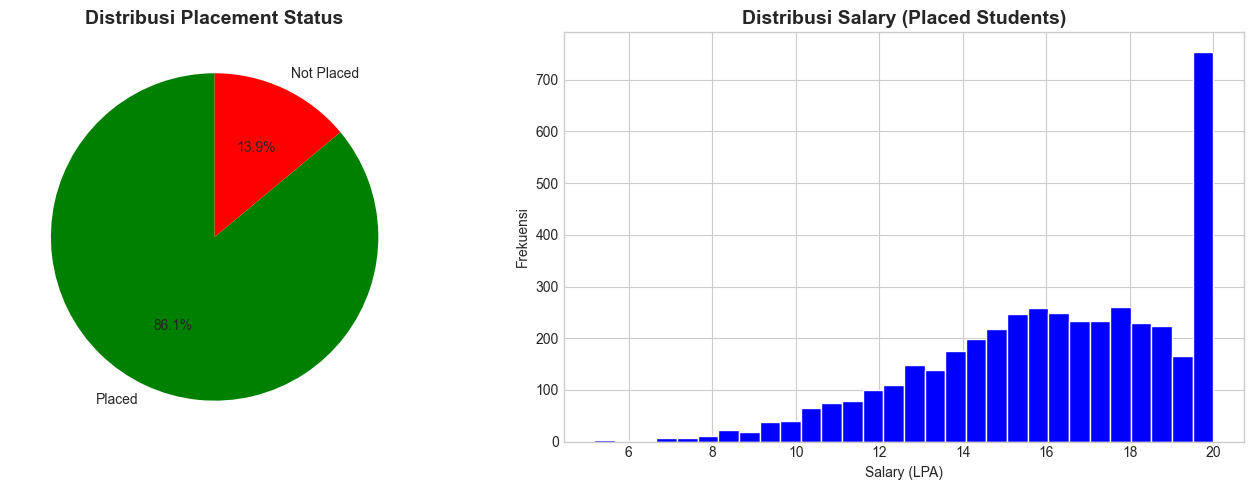

Placed: 4303 | Not Placed: 697
Imbalance ratio: 6.2:1


In [ ]:
# Distribusi target klasifikasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Placement status
placement_counts = df['placement_status'].value_counts()
axes[0].pie(placement_counts.values, labels=placement_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['green', 'red'])
axes[0].set_title('Distribusi Placement Status', fontsize=14, fontweight='bold')

# Plot 2: Distribusi salary
df[df['salary_lpa'] > 0]['salary_lpa'].hist(ax=axes[1], bins=30,
                                             color='blue', edgecolor='white')
axes[1].set_title('Distribusi Salary (Placed Students)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Salary (LPA)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()
print(f'Placed: {placement_counts["Placed"]} | Not Placed: {placement_counts["Not Placed"]}')
print(f'Imbalance ratio: {placement_counts["Placed"]/placement_counts["Not Placed"]:.1f}:1')

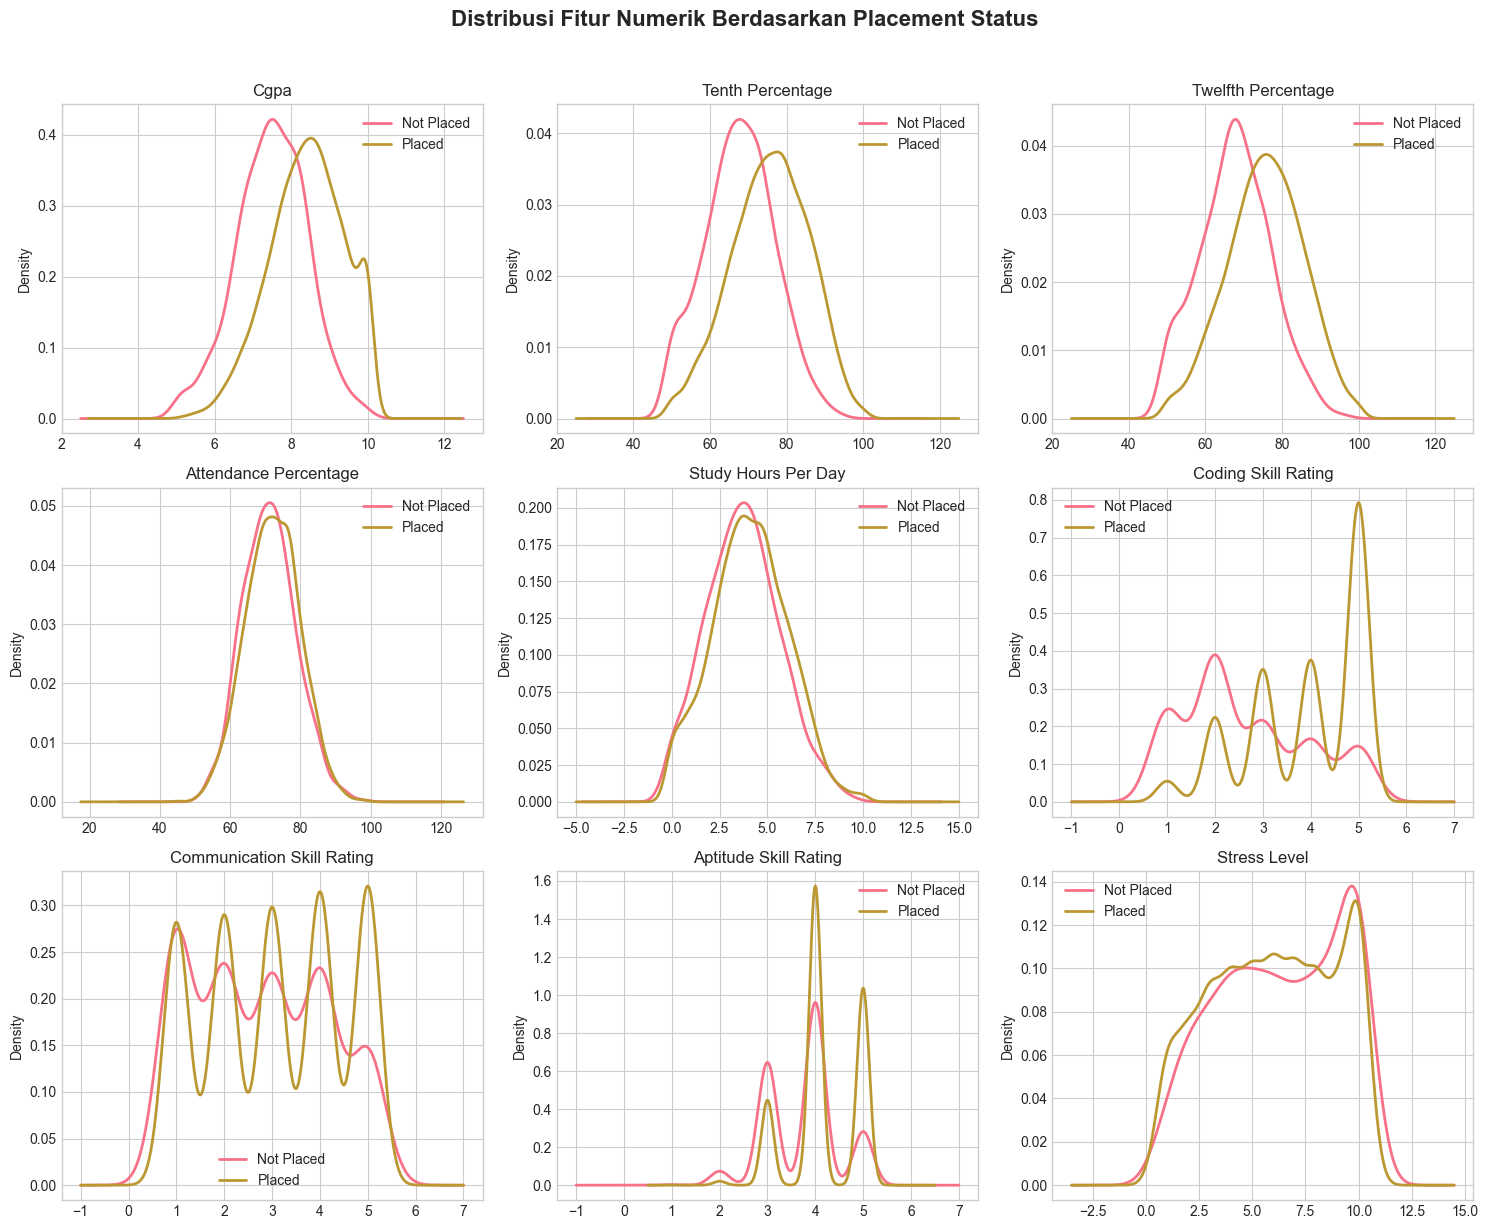

In [ ]:
# Distribusi fitur numerik utama
num_cols = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'attendance_percentage',
            'study_hours_per_day', 'coding_skill_rating', 'communication_skill_rating',
            'aptitude_skill_rating', 'stress_level']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.groupby('placement_status')[col].plot(kind='kde', ax=axes[i],
                                              legend=True, linewidth=2)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur Numerik Berdasarkan Placement Status', y=1.02,
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

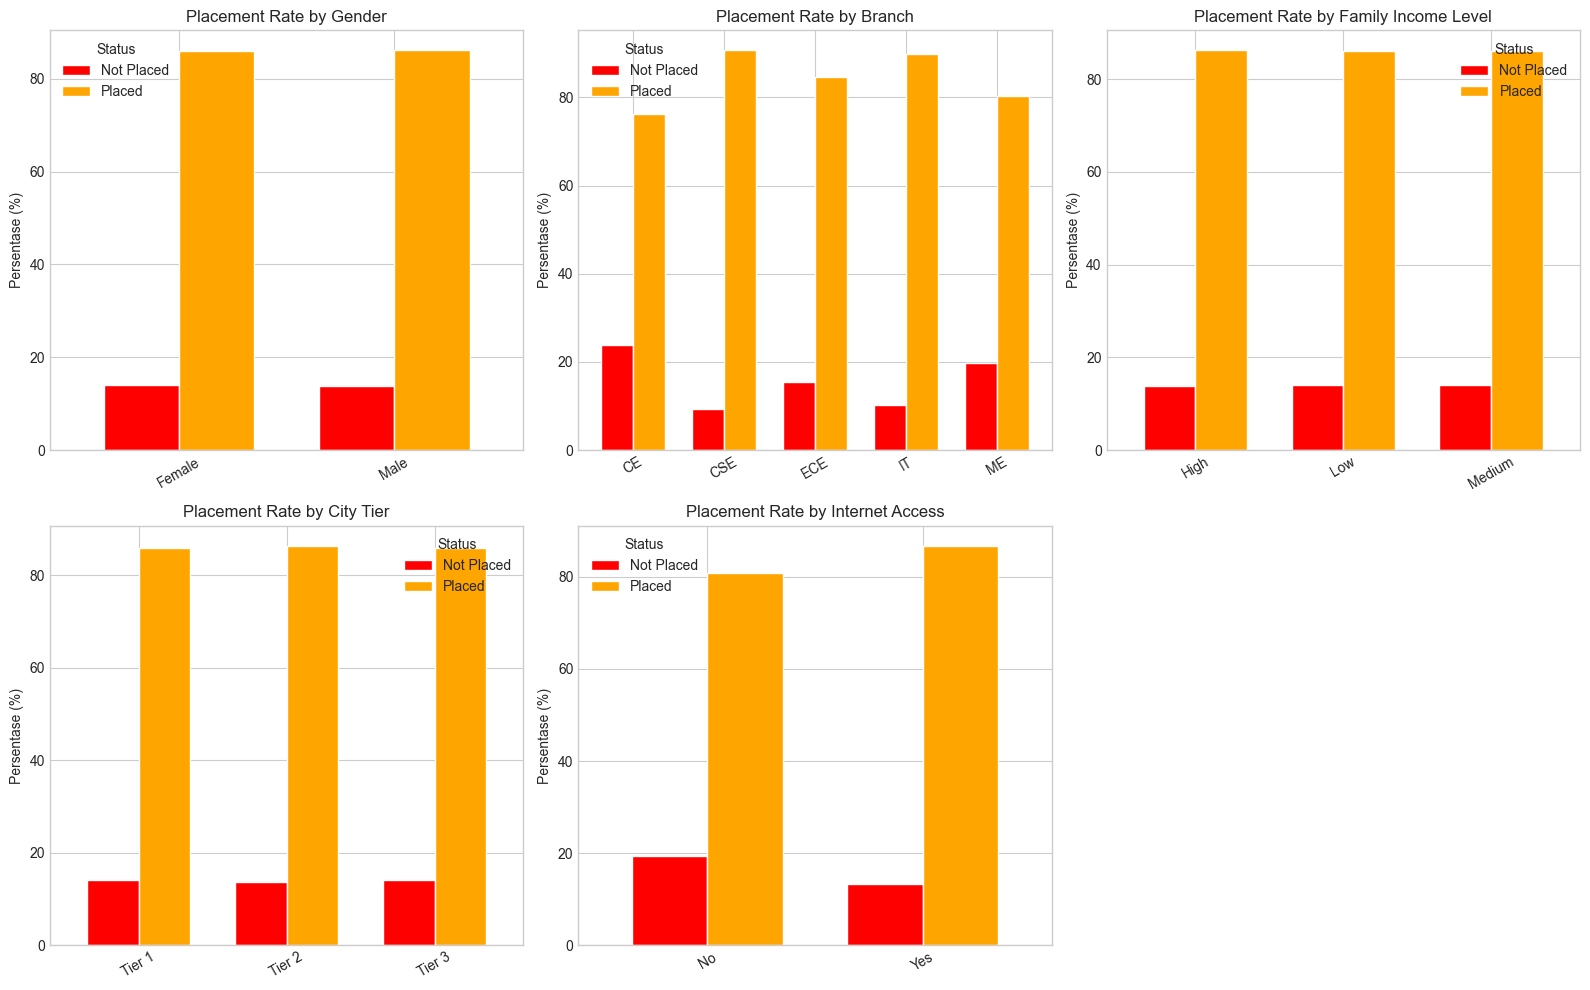

In [ ]:
# Analisis fitur kategorik
cat_cols = ['gender', 'branch', 'family_income_level', 'city_tier', 'internet_access']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['placement_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['red', 'orange'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'Placement Rate by {col.replace("_", " ").title()}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Status')

axes[5].axis('off')
plt.tight_layout()
plt.show()

### Correlation : Analysis untuk mengidentifikasi adanya hubungan antara fitur, agar mendapatkan info

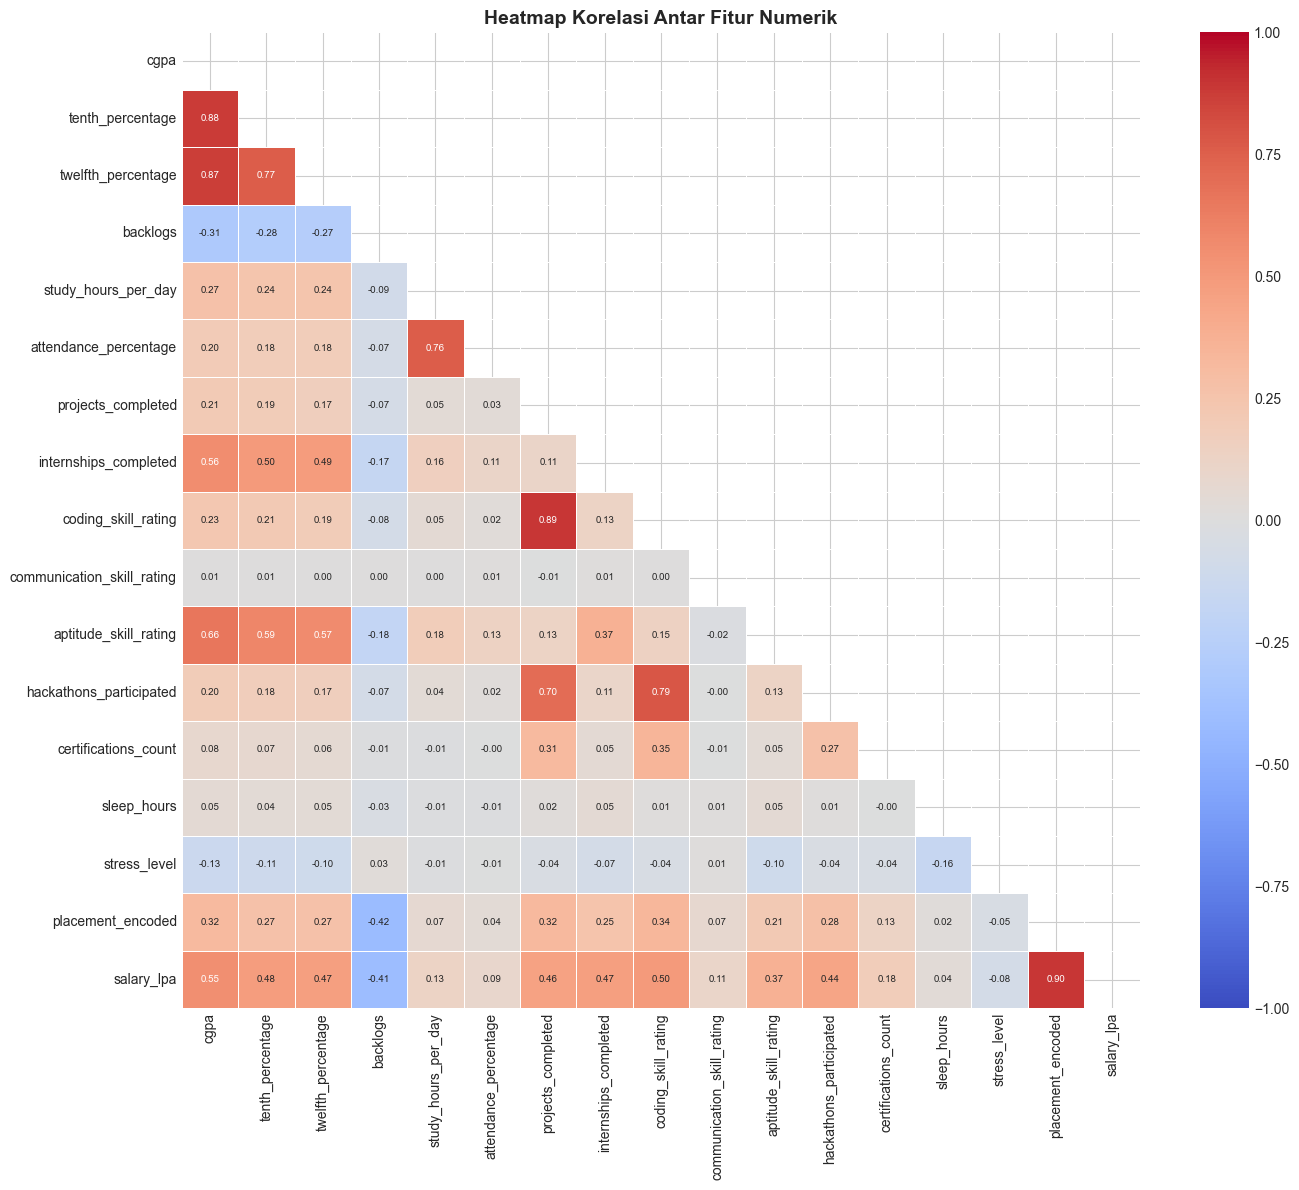

Korelasi terhadap placement_encoded:
placement_encoded             1.000000
salary_lpa                    0.895356
coding_skill_rating           0.343219
projects_completed            0.322796
cgpa                          0.315614
hackathons_participated       0.275848
tenth_percentage              0.269680
twelfth_percentage            0.268454
internships_completed         0.254189
aptitude_skill_rating         0.213778
certifications_count          0.125657
communication_skill_rating    0.074704
study_hours_per_day           0.065022
attendance_percentage         0.042426
sleep_hours                   0.016469
stress_level                 -0.045556
backlogs                     -0.415297


In [ ]:
# Buat copy dengan label encoding untuk korelasi
df_corr = df.copy()
df_corr['placement_encoded'] = (df_corr['placement_status'] == 'Placed').astype(int)

num_features = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
                'study_hours_per_day', 'attendance_percentage', 'projects_completed',
                'internships_completed', 'coding_skill_rating', 'communication_skill_rating',
                'aptitude_skill_rating', 'hackathons_participated', 'certifications_count',
                'sleep_hours', 'stress_level', 'placement_encoded', 'salary_lpa']

corr_matrix = df_corr[num_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Korelasi terhadap placement_encoded:')
print(corr_matrix['placement_encoded'].sort_values(ascending=False).to_string())

#### Adanya korelasi positif tinggi antara salary_lpa dengan placement_encoded, tenth_percentage dan twelveth_percentage dengan cgpa, dan projects_completed dengan coding_skill_rating

### Handling Missing Value

In [17]:
print('=== Missing Values Analysis ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

print(f'\nDistribusi extracurricular_involvement (sebelum imputasi):')
print(df['extracurricular_involvement'].value_counts(dropna=False))

=== Missing Values Analysis ===
                             Missing Count  Missing %
extracurricular_involvement           1006      20.12

Distribusi extracurricular_involvement (sebelum imputasi):
extracurricular_involvement
Medium    1501
Low       1485
High      1008
NaN       1006
Name: count, dtype: int64


### Feature Engineering

In [18]:
def engineer_features(df):
    df = df.copy()
    
    # Feature 1: Academic composite score
    df['academic_score'] = (df['cgpa'] * 10 * 0.5 +
                            df['tenth_percentage'] * 0.25 +
                            df['twelfth_percentage'] * 0.25)
    
    # Feature 2: Skill composite
    df['skill_composite'] = (df['coding_skill_rating'] +
                             df['communication_skill_rating'] +
                             df['aptitude_skill_rating']) / 3
    
    # Feature 3: Experience score
    df['experience_score'] = (df['projects_completed'] +
                              df['internships_completed'] * 2 +
                              df['hackathons_participated'] +
                              df['certifications_count'])
    
    # Feature 4: Study efficiency (study hours vs attendance)
    df['study_efficiency'] = df['study_hours_per_day'] * df['attendance_percentage'] / 100
    
    return df

df = engineer_features(df)
print('Fitur baru berhasil dibuat:')
print(df[['academic_score', 'skill_composite', 'experience_score', 'study_efficiency']].describe())

Fitur baru berhasil dibuat:
       academic_score  skill_composite  experience_score  study_efficiency
count     5000.000000      5000.000000       5000.000000       5000.000000
mean        78.689105         3.623467         16.334800          3.027267
std          9.692437         0.697908          5.086362          1.687373
min         50.100000         1.333333          1.000000          0.000000
25%         72.068750         3.000000         13.000000          1.807375
50%         79.025000         3.666667         17.000000          2.864200
75%         85.750000         4.000000         20.000000          4.095700
max         98.925000         5.000000         30.000000          9.810000


### Train-Test Split(80 : 20)

In [19]:
# Definisi fitur
FEATURES_TO_DROP = ['Student_ID', 'placement_status', 'salary_lpa']
categorical_cols = ['gender', 'branch', 'part_time_job', 'family_income_level',
                    'city_tier', 'internet_access', 'extracurricular_involvement']
numerical_cols = [c for c in df.columns if c not in FEATURES_TO_DROP + categorical_cols]

X = df.drop(columns=FEATURES_TO_DROP)
y_cls = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})
y_reg = df['salary_lpa']

# Split untuk Klasifikasi (stratified)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Split untuk Regresi (hanya data placed agar salary bermakna)
placed_mask = y_cls == 1
X_placed = X[placed_mask]
y_placed = y_reg[placed_mask]
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_placed, y_placed, test_size=0.2, random_state=42
)

print(f'=== KLASIFIKASI ===')
print(f'Train: {X_train_cls.shape} | Test: {X_test_cls.shape}')
print(f'Train class ratio: {y_train_cls.mean():.3f}')
print(f'Test class ratio:  {y_test_cls.mean():.3f}')
print(f'\n=== REGRESI (Placed only) ===')
print(f'Train: {X_train_reg.shape} | Test: {X_test_reg.shape}')

=== KLASIFIKASI ===
Train: (4000, 26) | Test: (1000, 26)
Train class ratio: 0.861
Test class ratio:  0.861

=== REGRESI (Placed only) ===
Train: (3442, 26) | Test: (861, 26)


In [20]:
# Preprocessing Pipeline (shared)
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print('Preprocessor Pipeline berhasil dibuat')
print(f'Numerical features ({len(numerical_cols)}): {numerical_cols[:5]}...')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Preprocessor Pipeline berhasil dibuat
Numerical features (19): ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day']...
Categorical features (7): ['gender', 'branch', 'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']


### Modeling (LogReg, RF, Gradient Boosting Classifier) + Metrics (Accuracy, Precision, F1, Recall, ROC-AUC)

In [21]:
def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    return metrics

# --- Model 1: Logistic Regression ---
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
lr_pipeline.fit(X_train_cls, y_train_cls)
print('Logistic Regression trained')

# --- Model 2: Random Forest ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10,
                                          random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train_cls, y_train_cls)
print('Random Forest trained')

# --- Model 3: Gradient Boosting ---
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                               max_depth=4, random_state=42))
])
gb_pipeline.fit(X_train_cls, y_train_cls)
print('Gradient Boosting trained')

Logistic Regression trained
Random Forest trained
Gradient Boosting trained


=== HASIL KLASIFIKASI ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     0.891     0.9169  0.9605    0.9382   0.9103
Random Forest           0.890     0.9007  0.9803    0.9388   0.9052
Gradient Boosting       0.877     0.9118  0.9489    0.9300   0.9052


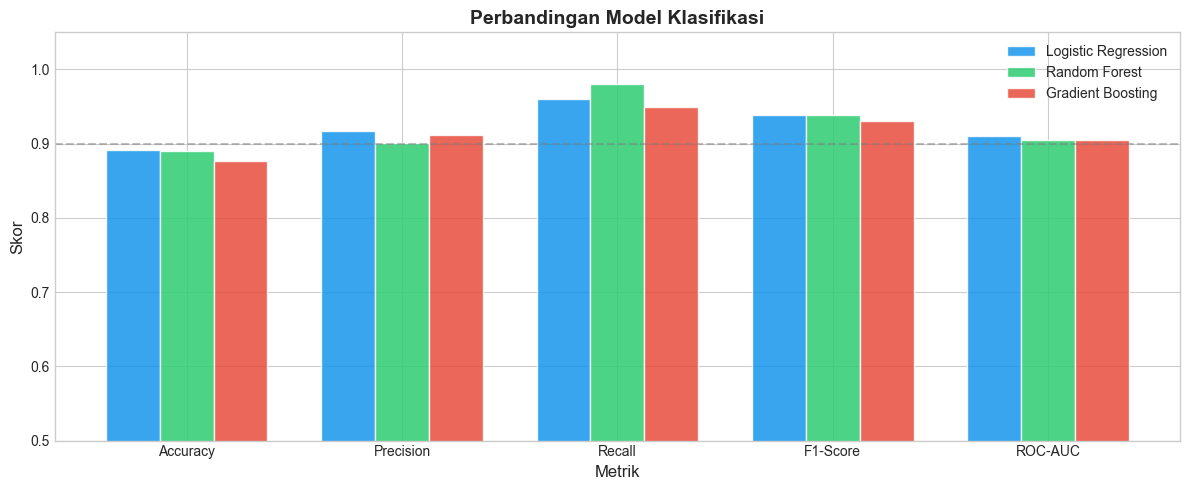

In [ ]:
# Evaluasi Klasifikasi
cls_results = []
for name, model in [('Logistic Regression', lr_pipeline),
                    ('Random Forest', rf_pipeline),
                    ('Gradient Boosting', gb_pipeline)]:
    cls_results.append(evaluate_classifier(model, X_test_cls, y_test_cls, name))

cls_df = pd.DataFrame(cls_results).set_index('Model')
print('=== HASIL KLASIFIKASI ===')
print(cls_df.round(4).to_string())

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#1595eb", '#2ecc71', '#e74c3c']

for i, (idx, row) in enumerate(cls_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot],
           width, label=idx, color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Model Klasifikasi', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='Threshold 90%')
plt.tight_layout()
plt.show()

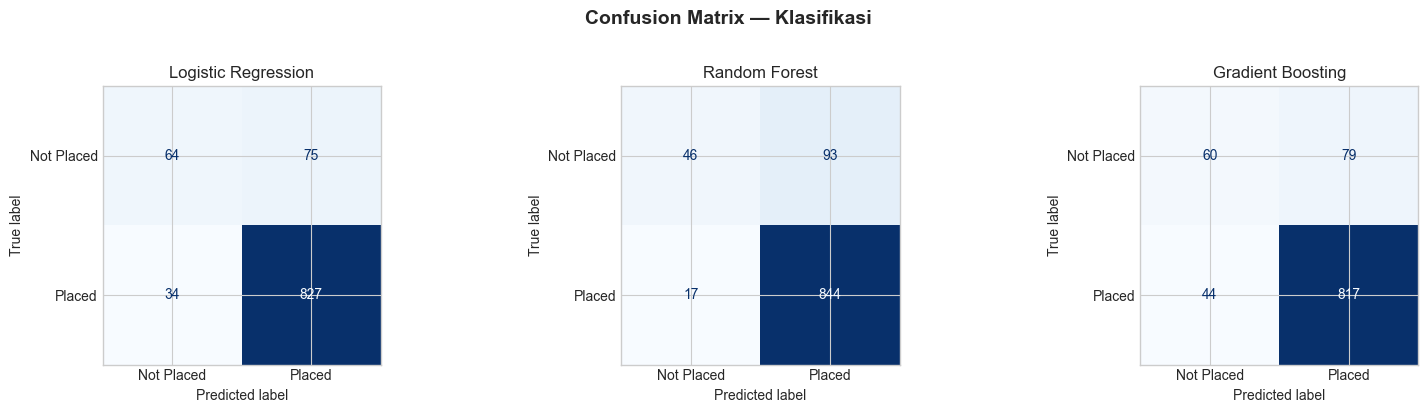


 Model terbaik (F1): Random Forest — F1=0.9388


In [ ]:
# Confusion Matrix untuk model terbaik
best_cls_model_name = cls_df['F1-Score'].idxmax()
best_cls_models = {'Logistic Regression': lr_pipeline,
                   'Random Forest': rf_pipeline,
                   'Gradient Boosting': gb_pipeline}
best_cls = best_cls_models[best_cls_model_name]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, model) in enumerate(best_cls_models.items()):
    y_pred = model.predict(X_test_cls)
    cm = confusion_matrix(y_test_cls, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Placed', 'Placed'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=12)

plt.suptitle('Confusion Matrix — Klasifikasi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\n Model terbaik (F1): {best_cls_model_name} — F1={cls_df.loc[best_cls_model_name, "F1-Score"]:.4f}')

### Hasil : Dari Hasil klasifikasi, LogReg unggul pada 3 metric (Accuracy, Precision, ROC-AUC, tetapi pada Recall dan F1, Random Forest lebih unggul, dan F1 Score dipakai menjadi metric utama untuk menghindari distribusi yang tidak seimbang.)

### Regression Modeling (Ridge Regression, RF Regressor, Gradient Boosting Regressor)

In [25]:
def evaluate_regressor(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R² Score': r2_score(y_test, y_pred)
    }

# --- Model 1: Ridge Regression ---
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train_reg, y_train_reg)
print('Ridge Regression trained')

# --- Model 2: Random Forest Regressor ---
rfr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10,
                                         random_state=42, n_jobs=-1))
])
rfr_pipeline.fit(X_train_reg, y_train_reg)
print('Random Forest Regressor trained')

# --- Model 3: Gradient Boosting Regressor ---
gbr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                             max_depth=4, random_state=42))
])
gbr_pipeline.fit(X_train_reg, y_train_reg)
print('Gradient Boosting Regressor trained')

Ridge Regression trained
Random Forest Regressor trained
Gradient Boosting Regressor trained


=== HASIL REGRESI ===
                      MAE    RMSE  R² Score
Model                                      
Ridge Regression   1.1311  1.4067    0.7717
Random Forest      1.1833  1.4926    0.7430
Gradient Boosting  1.1095  1.4082    0.7713


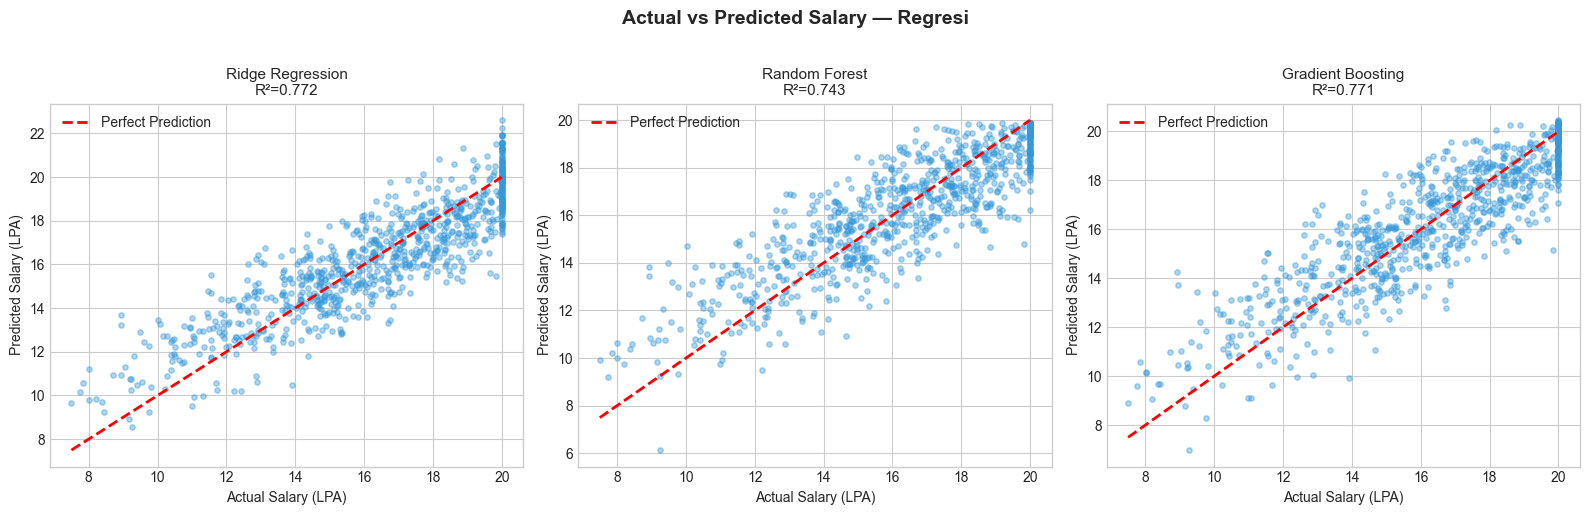


Model terbaik (R²): Ridge Regression — R²=0.7717


In [ ]:
# Evaluasi Regresi
reg_results = []
for name, model in [('Ridge Regression', ridge_pipeline),
                    ('Random Forest', rfr_pipeline),
                    ('Gradient Boosting', gbr_pipeline)]:
    reg_results.append(evaluate_regressor(model, X_test_reg, y_test_reg, name))

reg_df = pd.DataFrame(reg_results).set_index('Model')
print('=== HASIL REGRESI ===')
print(reg_df.round(4).to_string())

# Visualisasi: Actual vs Predicted untuk model terbaik
best_reg_name = reg_df['R² Score'].idxmax()
best_reg_models = {'Ridge Regression': ridge_pipeline,
                   'Random Forest': rfr_pipeline,
                   'Gradient Boosting': gbr_pipeline}
best_reg = best_reg_models[best_reg_name]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (name, model) in enumerate(best_reg_models.items()):
    y_pred = model.predict(X_test_reg)
    axes[i].scatter(y_test_reg, y_pred, alpha=0.4, color='#3498db', s=15)
    min_v, max_v = y_test_reg.min(), y_test_reg.max()
    axes[i].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect Prediction')
    r2 = r2_score(y_test_reg, y_pred)
    axes[i].set_title(f'{name}\nR²={r2:.3f}', fontsize=11)
    axes[i].set_xlabel('Actual Salary (LPA)')
    axes[i].set_ylabel('Predicted Salary (LPA)')
    axes[i].legend()

plt.suptitle('Actual vs Predicted Salary — Regresi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\nModel terbaik (R²): {best_reg_name} — R²={reg_df.loc[best_reg_name, "R² Score"]:.4f}')

=== RINGKASAN AKHIR ===

Klasifikasi:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     0.891     0.9169  0.9605    0.9382   0.9103
Random Forest           0.890     0.9007  0.9803    0.9388   0.9052
Gradient Boosting       0.877     0.9118  0.9489    0.9300   0.9052

Model Terbaik Klasifikasi: Random Forest

Regresi:
                      MAE    RMSE  R² Score
Model                                      
Ridge Regression   1.1311  1.4067    0.7717
Random Forest      1.1833  1.4926    0.7430
Gradient Boosting  1.1095  1.4082    0.7713

Model Terbaik Regresi: Ridge Regression


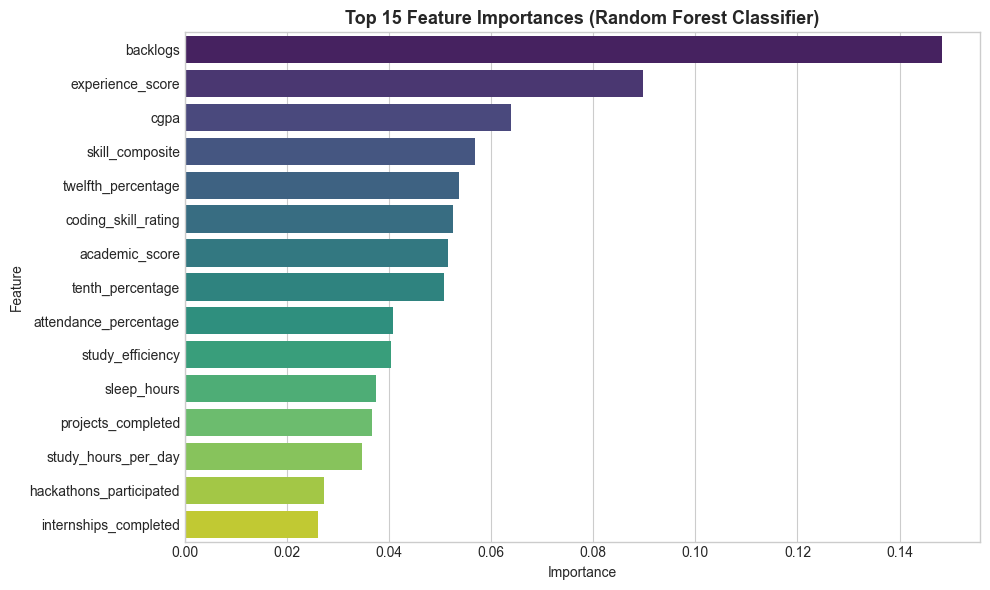

In [ ]:
# Feature importance dari model terbaik
print('=== RINGKASAN AKHIR ===')
print('\nKlasifikasi:')
print(cls_df.round(4).to_string())
print(f'\nModel Terbaik Klasifikasi: {cls_df["F1-Score"].idxmax()}')

print('\nRegresi:')
print(reg_df.round(4).to_string())
print(f'\nModel Terbaik Regresi: {reg_df["R² Score"].idxmax()}')

# Feature importance untuk Random Forest (interpretabilitas)
import re
rf_model = rf_pipeline.named_steps['classifier']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

# Get feature names
num_names = numerical_cols
cat_names = list(preprocessor_fitted.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
all_feature_names = num_names + cat_names

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest Classifier)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Kesimpulan : Gradient Boosting